In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("train 25K.csv")

In [4]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25001 entries, 0 to 25000
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         25001 non-null  int64 
 1   age        25001 non-null  int64 
 2   job        25001 non-null  object
 3   marital    25001 non-null  object
 4   education  25001 non-null  object
 5   default    25001 non-null  object
 6   balance    25001 non-null  int64 
 7   housing    25001 non-null  object
 8   loan       25001 non-null  object
 9   contact    25001 non-null  object
 10  day        25001 non-null  int64 
 11  month      25001 non-null  object
 12  duration   25001 non-null  int64 
 13  campaign   25001 non-null  int64 
 14  pdays      25001 non-null  int64 
 15  previous   25001 non-null  int64 
 16  poutcome   25001 non-null  object
 17  y          25001 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 3.4+ MB


In [6]:
df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
x = df.drop("y", axis = 1)
Y = df["y"]

<Axes: >

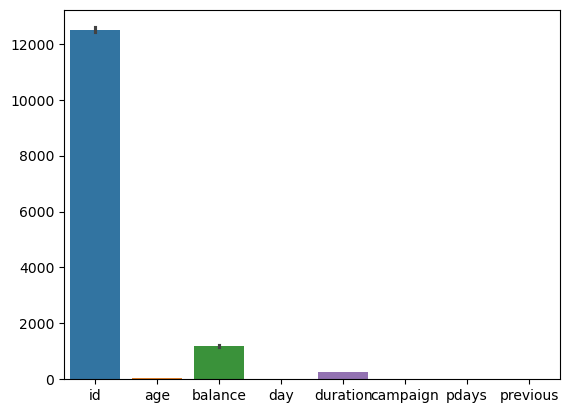

In [8]:
sns.barplot(x)

In [9]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [10]:

le = LabelEncoder()

df['default'] = le.fit_transform(df['default'])
df['housing'] = le.fit_transform(df['housing'])
df['loan'] = le.fit_transform(df['loan'])
df['y'] = le.fit_transform(df['y'])

In [11]:
df = pd.get_dummies(
    df,
    columns=['job', 'marital', 'education', 'contact', 'month', 'poutcome'],
    drop_first=True
)

In [12]:
df.head()

,id,age,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,0,42,0,7,0,0,25,117,3,-1,...,False,False,False,False,False,False,False,False,False,True
1,1,38,0,514,0,0,18,185,1,-1,...,False,True,False,False,False,False,False,False,False,True
2,2,36,0,602,1,0,14,111,2,-1,...,False,False,False,True,False,False,False,False,False,True
3,3,27,0,34,1,0,28,10,2,-1,...,False,False,False,True,False,False,False,False,False,True
4,4,26,0,889,1,0,3,902,1,-1,...,False,False,False,False,False,False,False,False,False,True


In [13]:
X = df.drop('y', axis=1)
y = df['y']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    
)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

E:\Anaconda Distributor\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [17]:
X_train.head()

,id,age,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
9338,9338,32,1,-947,1,1,18,148,5,-1,...,False,True,False,False,False,False,False,False,False,True
24212,24212,33,0,0,0,0,4,111,1,-1,...,False,False,False,False,False,False,False,False,False,True
22608,22608,43,0,0,0,0,9,194,1,-1,...,True,False,False,False,False,False,False,False,False,True
16068,16068,33,0,3160,1,0,15,449,1,-1,...,False,True,False,False,False,False,False,False,False,True
50,50,40,0,1749,1,0,19,97,1,-1,...,False,False,False,True,False,False,False,False,False,True


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [20]:
# Prediction
y_pred = model.predict(X_test)

# Probability (ROC-AUC ke liye)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9309425409945341
Precision: 0.7994227994227994
Recall   : 0.5937834941050375
F1-Score : 0.6814268142681427
ROC-AUC  : 0.9578899546079402


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6568
           1       0.80      0.59      0.68       933

    accuracy                           0.93      7501
   macro avg       0.87      0.79      0.82      7501
weighted avg       0.93      0.93      0.93      7501



In [22]:
print(confusion_matrix(y_test, y_pred))

[[6429  139]
 [ 379  554]]


In [23]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [24]:
import shap

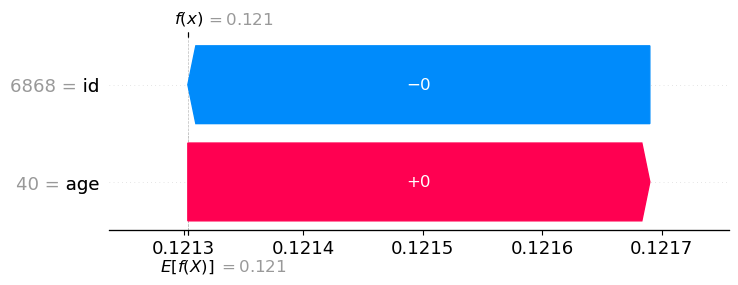

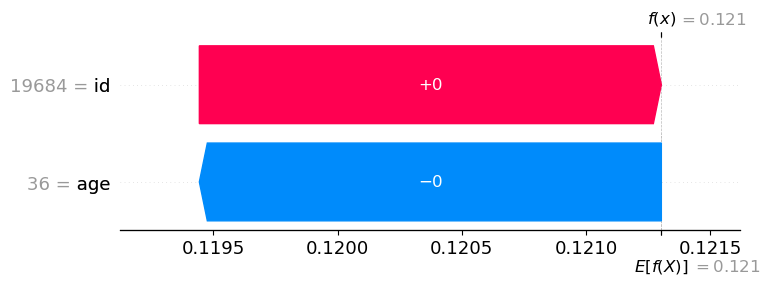

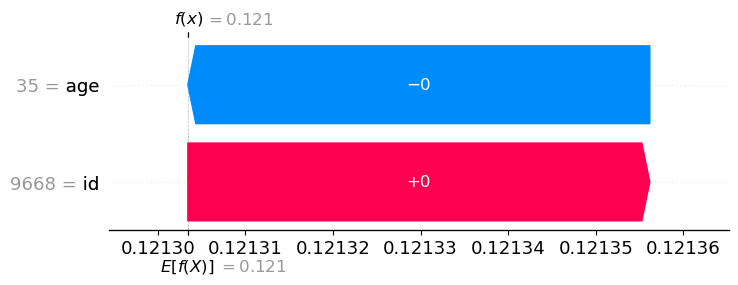

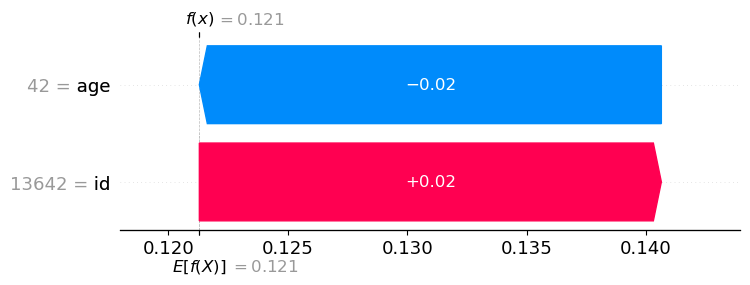

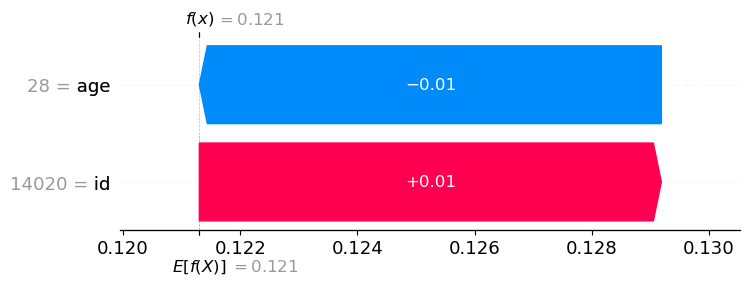

In [25]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

for i in range(5):
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[1][i],
            base_values=explainer.expected_value[1],
            data=X_test.iloc[i],
            feature_names=X_test.columns
        )
    )

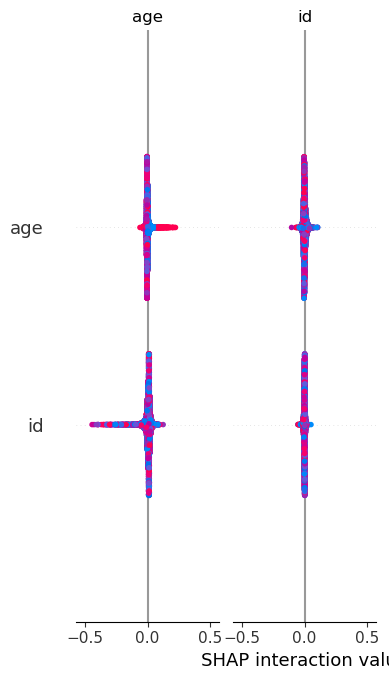

In [27]:
shap.summary_plot(shap_values, X_test)